<a href="https://colab.research.google.com/github/ingJuanArenas/simulacionYahtzeeEA1/blob/main/Simulaci%C3%B3nEA1Yahtzee.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


NUM_SIMULACIONES_POR_DECISION = 300
random.seed(42)


ORDEN_CATEGORIAS_YAHTZEE = [
    "ones","twos","threes","fours","fives","sixes",
    "threeOfKind","fourOfKind","fullHouse","smallStraight",
    "largeStraight","yahtzee","chance"
]

@dataclass
class EstadoJugador:

    nombre: str
    puntuaciones: Dict[str, Optional[int]] = field(default_factory=lambda: {c: None for c in ORDEN_CATEGORIAS_YAHTZEE})
    total: int = 0

    def categorias_disponibles(self) -> List[str]:
        return [c for c,v in self.puntuaciones.items() if v is None]

    def establecer_puntuacion(self, categoria: str, puntos: int) -> None:
        """Asigna puntos a una categoría y actualiza el total del jugador."""
        self.puntuaciones[categoria] = puntos
        self.total = sum(v for v in self.puntuaciones.values() if v is not None)

@dataclass
class EstadisticasPartida:
    total_lanzamientos_dados: int = 0
    historial_caras: Counter = field(default_factory=Counter)

    def actualizar_con_tirada(self, valores: List[int]) -> None:
        """Registra los resultados de una tirada de dados para nuestras estadísticas."""
        self.total_lanzamientos_dados += len(valores) # Contamos cada dado individualmente
        self.historial_caras.update(valores)

@dataclass
class EstadoJuego:
    jugadores: List[EstadoJugador]
    indice_jugador_actual: int = 0
    turno_en_ronda: int = 0
    valores_dados: List[int] = field(default_factory=lambda: [0]*5)
    dados_bloqueados: List[bool] = field(default_factory=lambda: [False]*5)
    tiradas_restantes: int = 3
    estadisticas: EstadisticasPartida = field(default_factory=EstadisticasPartida)

    def reiniciar_turno(self):
        """Prepara todo para el inicio de un nuevo turno: dados a cero, nada bloqueado, 3 tiradas."""
        self.valores_dados = [0]*5
        self.dados_bloqueados = [False]*5
        self.tiradas_restantes = 3

    @property
    def jugador_actual(self) -> EstadoJugador:
        return self.jugadores[self.indice_jugador_actual]

    def avanzar_jugador(self):
        self.indice_jugador_actual = (self.indice_jugador_actual + 1) % len(self.jugadores)
        if self.indice_jugador_actual == 0:
            self.turno_en_ronda += 1


def lanzar_un_dado() -> int:
    return random.randint(1, 6)

def tirar_dados_no_bloqueados(valores: List[int], bloqueados: List[bool]) -> None:
    for i, esta_bloqueado in enumerate(bloqueados):
        if not esta_bloqueado:
            valores[i] = lanzar_un_dado()

def tiene_secuencia_consecutiva(valores: List[int], longitud_necesaria: int) -> bool:
    """Comprueba si en nuestros dados hay una escalera """
    unicos = sorted(set(valores))
    if not unicos:
        return False

    # Recorremos para ver si hay 4 o 5 números seguidos.
    consecutivos_actual = 1
    consecutivos_mas_largos = 1
    for i in range(1, len(unicos)):
        if unicos[i] == unicos[i-1] + 1:
            consecutivos_actual += 1
            consecutivos_mas_largos = max(consecutivos_mas_largos, consecutivos_actual)
        else:
            consecutivos_actual = 1 # Se rompió la secuencia, reiniciamos.
    return consecutivos_mas_largos >= longitud_necesaria


def puntuar_mano_dados(categoria: str, dados: List[int]) -> int:
    conteo = Counter(dados)
    frecuencias = list(conteo.values())
    suma_total_dados = sum(dados)

    # Categorías simples (unos, doses, etc.)
    if categoria in ["ones","twos","threes","fours","fives","sixes"]:
        numero_a_contar = {"ones":1, "twos":2, "threes":3, "fours":4, "fives":5, "sixes":6}[categoria]
        return conteo.get(numero_a_contar, 0) * numero_a_contar
    # Tres de una clase
    if categoria == "threeOfKind":
        return suma_total_dados if any(f >= 3 for f in frecuencias) else 0
    # Cuatro de una clase
    if categoria == "fourOfKind":
        return suma_total_dados if any(f >= 4 for f in frecuencias) else 0
    # Full House
    if categoria == "fullHouse":
        return 25 if (2 in frecuencias and 3 in frecuencias) else 0
    # Escalera Pequeña
    if categoria == "smallStraight":
        return 30 if tiene_secuencia_consecutiva(dados, 4) else 0
    # Escalera Grande
    if categoria == "largeStraight":
        return 40 if tiene_secuencia_consecutiva(dados, 5) else 0
    # ¡YAHTZEE!
    if categoria == "yahtzee":
        return 50 if 5 in frecuencias else 0
    # Suerte (Chance)
    if categoria == "chance":
        return suma_total_dados
    return 0

def encontrar_mejor_categoria_puntuacion(dados: List[int], disponibles: List[str]) -> Tuple[str, int]:
    mejor_categoria, mejor_puntuacion = None, -1
    for categoria in disponibles:
        puntuacion_actual = puntuar_mano_dados(categoria, dados)
        if puntuacion_actual > mejor_puntuacion:
            mejor_puntuacion = puntuacion_actual
            mejor_categoria = categoria
    return mejor_categoria, mejor_puntuacion


def generar_todas_las_mascaras_bloqueo() -> List[List[bool]]:
    mascaras = []
    for m in range(32):
        mascara = [(m >> i) & 1 == 1 for i in range(5)]
        mascaras.append(mascara)
    return mascaras

def simular_valor_esperado_despues_de_bloqueo(
    valores_actuales: List[int], mascara_bloqueo: List[bool], tiradas_restantes: int,
    categorias_disponibles: List[str], num_simulaciones: int
) -> float:
    if tiradas_restantes <= 0: # Si no quedan tiradas, solo puntuamos lo que tenemos.
        _, puntuacion = encontrar_mejor_categoria_puntuacion(valores_actuales, categorias_disponibles)
        return float(puntuacion)

    # Preparamos los dados que sí vamos a guardar.
    dados_guardados = [v if mascara_bloqueo[i] else None for i, v in enumerate(valores_actuales)]
    indices_dados_no_bloqueados = [i for i, esta_bloqueado in enumerate(mascara_bloqueo) if not esta_bloqueado]

    puntuacion_total_simulada = 0.0
    for _ in range(num_simulaciones):
        dados_para_simulacion = list(dados_guardados) # Copia de los dados guardados.
        valores_temporales = list(valores_actuales) # Copia de los valores actuales para modificar.

        # Tiramos los dados no bloqueados el número de veces restantes.
        for _tirada in range(tiradas_restantes):
            for idx in indices_dados_no_bloqueados:
                valores_temporales[idx] = lanzar_un_dado()

        # Combinamos los dados guardados con los nuevos resultados de la simulación.
        for i in range(5):
            dados_para_simulacion[i] = dados_para_simulacion[i] if dados_para_simulacion[i] is not None else valores_temporales[i]

        # Vemos qué puntuación máxima obtendríamos con esta mano simulada.
        _, puntuacion_obtenida = encontrar_mejor_categoria_puntuacion(dados_para_simulacion, categorias_disponibles)
        puntuacion_total_simulada += puntuacion_obtenida

    # Calculamos el promedio de todas las simulaciones.
    return puntuacion_total_simulada / num_simulaciones if num_simulaciones > 0 else 0.0

def elegir_mascara_bloqueo_montecarlo(
    valores_dados_actuales: List[int], tiradas_restantes: int,
    categorias_disponibles: List[str], num_simulaciones_por_decision: int = NUM_SIMULACIONES_POR_DECISION
) -> List[bool]:
    mejor_mascara = None
    mejor_valor_esperado = -1.0

    # Probamos cada posible combinación de bloqueo de dados.
    for mascara_posible in generar_todas_las_mascaras_bloqueo():
        # Simulamos cuánto ganaríamos si usamos esta máscara y hacemos las tiradas restantes.
        valor_esperado_actual = simular_valor_esperado_despues_de_bloqueo(
            valores_dados_actuales, mascara_posible, tiradas_restantes - 1, categorias_disponibles, num_simulaciones_por_decision
        )
        # Si esta máscara da un mejor valor esperado, la guardamos.
        if valor_esperado_actual > mejor_valor_esperado:
            mejor_valor_esperado = valor_esperado_actual
            mejor_mascara = mascara_posible
    return mejor_mascara


def jugar_un_turno(estado: EstadoJuego, mostrar_detalles: bool = False):
    jugador = estado.jugador_actual
    estado.reiniciar_turno() # Empezamos el turno con dados frescos.

    # Primera tirada (obligatoria)
    tirar_dados_no_bloqueados(estado.valores_dados, estado.dados_bloqueados)
    estado.estadisticas.actualizar_con_tirada(estado.valores_dados)
    estado.tiradas_restantes -= 1
    if mostrar_detalles: print(f"\n{jugador.nombre} — Tirada 1: {estado.valores_dados}")

    # Intentos de reroll (hasta que se acaben las tiradas o se planten)
    while estado.tiradas_restantes > 0:

        mascara_para_bloquear = elegir_mascara_bloqueo_montecarlo(
            estado.valores_dados, estado.tiradas_restantes, jugador.categorias_disponibles()
        )


        if all(mascara_para_bloquear):
            if mostrar_detalles: print(f"{jugador.nombre} decide plantarse con: {estado.valores_dados}")
            break

        estado.dados_bloqueados = list(mascara_para_bloquear) # Aplicamos la decisión de bloqueo.
        tirar_dados_no_bloqueados(estado.valores_dados, estado.dados_bloqueados)
        estado.estadisticas.actualizar_con_tirada(estado.valores_dados)
        estado.tiradas_restantes -= 1
        if mostrar_detalles: print(f"{jugador.nombre} — Tirada {3 - estado.tiradas_restantes}: {estado.valores_dados} | Bloqueados: {mascara_para_bloquear}")

    # Al final del turno, el jugador puntúa la mejor categoría disponible con los dados finales.
    categoria_elegida, puntuacion_obtenida = encontrar_mejor_categoria_puntuacion(estado.valores_dados, jugador.categorias_disponibles())
    jugador.establecer_puntuacion(categoria_elegida, puntuacion_obtenida)
    if mostrar_detalles: print(f"→ {jugador.nombre} elige '{categoria_elegida}' y anota {puntuacion_obtenida} pts. Total = {jugador.total}")

def iniciar_partida(mostrar_detalles_cada_turno: bool = False) -> EstadoJuego:

    jugadores_participantes = [EstadoJugador("Jugador 1"), EstadoJugador("Jugador 2")]
    estado_actual_juego = EstadoJuego(jugadores=jugadores_participantes)
    total_rondas = 13

    print("Iniciando simulación de Montecarlo ")
    for ronda in range(total_rondas):
        for _indice_jugador in range(len(jugadores_participantes)): # Cada jugador juega una vez por ronda.
            jugar_un_turno(estado_actual_juego, mostrar_detalles=mostrar_detalles_cada_turno)
            estado_actual_juego.avanzar_jugador()
    return estado_actual_juego


resultado_final_partida = iniciar_partida(mostrar_detalles_cada_turno=False)


Iniciando simulación de Montecarlo 



 el ganador es Jugador 2!

    Categoría  Jugador 1  Jugador 2
         ones          0          1
         twos          2          0
       threes          6          6
        fours          4          8
        fives          5         10
        sixes          6          6
  threeOfKind         17         16
   fourOfKind          0          0
    fullHouse          0          0
smallStraight         30         30
largeStraight          0         40
      yahtzee          0          0
       chance         21         18
------------------------------
PUNTUACIÓN TOTAL | Jugador 1: 91 | Jugador 2: 135

 ANÁLISIS DE DADOS (Validando  Montecarlo)
Teóricamente, cada cara de un dado perfecto debería salir un: 1/6 = 16.67%
 Cara 1: Salió 51 veces -> 13.08% (Diferencia vs Teoría: 3.59%)
 Cara 2: Salió 65 veces -> 16.67% (Diferencia vs Teoría: 0.00%) ¡Casi perfecta!
 Cara 3: Salió 67 veces -> 17.18% (Diferencia vs Teoría: 0.51%) ¡Casi perfecta!
 Cara 4: Salió 64 veces -> 16.41% (Diferenci

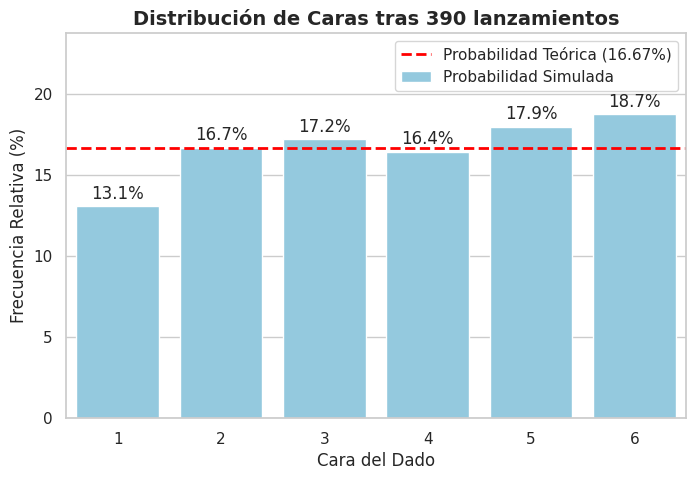

In [2]:
def mostrar_analisis_resultados(estado: EstadoJuego):

    sns.set_theme(style="whitegrid")

    jugador1, jugador2 = estado.jugadores
    if jugador1.total > jugador2.total:
        ganador = jugador1.nombre
    elif jugador2.total > jugador1.total:
        ganador = jugador2.nombre
    else:
        ganador = "Empate"

    print(f"\n el ganador es {ganador}!\n")


    df_puntuaciones = pd.DataFrame({
        "Categoría": ORDEN_CATEGORIAS_YAHTZEE,
        jugador1.nombre: [jugador1.puntuaciones[c] if jugador1.puntuaciones[c] is not None else 0 for c in ORDEN_CATEGORIAS_YAHTZEE],
        jugador2.nombre: [jugador2.puntuaciones[c] if jugador2.puntuaciones[c] is not None else 0 for c in ORDEN_CATEGORIAS_YAHTZEE]
    })


    print(df_puntuaciones.to_string(index=False))
    print("-" * 30)
    print(f"PUNTUACIÓN TOTAL | {jugador1.nombre}: {jugador1.total} | {jugador2.nombre}: {jugador2.total}")



    print("\n" + "="*50)
    print(" ANÁLISIS DE DADOS (Validando  Montecarlo)")
    print("="*50)
    print(f"Teóricamente, cada cara de un dado perfecto debería salir un: 1/6 = 16.67%")

    # frecuencias y probabilidades empíricas de cada cara.
    total_caras_contadas = sum(estado.estadisticas.historial_caras.values())
    numeros_cara = list(range(1, 7))
    frecuencias_caras = [estado.estadisticas.historial_caras.get(cara, 0) for cara in numeros_cara]
    probabilidades_observadas = [(frecuencia / total_caras_contadas) * 100 if total_caras_contadas else 0 for frecuencia in frecuencias_caras]


    for cara, frec, prob in zip(numeros_cara, frecuencias_caras, probabilidades_observadas):
        margen_error = abs(prob - 16.67)
        print(f" Cara {cara}: Salió {frec} veces -> {prob:.2f}% (Diferencia vs Teoría: {margen_error:.2f}%) ¡Casi perfecta!" if margen_error < 1 else f" Cara {cara}: Salió {frec} veces -> {prob:.2f}% (Diferencia vs Teoría: {margen_error:.2f}%)")


    plt.figure(figsize=(8, 5))


    bar_plot = sns.barplot(x=numeros_cara, y=probabilidades_observadas, color="skyblue", label="Probabilidad Simulada")


    plt.axhline(y=16.67, color='red', linestyle='--', linewidth=2, label='Probabilidad Teórica (16.67%)')


    plt.title(f"Distribución de Caras tras {estado.estadisticas.total_lanzamientos_dados} lanzamientos", fontsize=14, fontweight="bold")
    plt.xlabel("Cara del Dado")
    plt.ylabel("Frecuencia Relativa (%)")
    plt.ylim(0, max(probabilidades_observadas) + 5)
    plt.legend()


    for p in bar_plot.patches:
        bar_plot.annotate(format(p.get_height(), '.1f') + '%',
                          (p.get_x() + p.get_width() / 2., p.get_height()),
                          ha = 'center', va = 'center',
                          xytext = (0, 9),
                          textcoords = 'offset points')

    plt.show()



mostrar_analisis_resultados(resultado_final_partida)
